In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# when the distribution is skewed
df = pd.read_csv('placement.csv')

In [3]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


C:\Users\parth\AppData\Local\Temp\ipykernel_17256\3082534968.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['cgpa'], color='blue', shade=True)


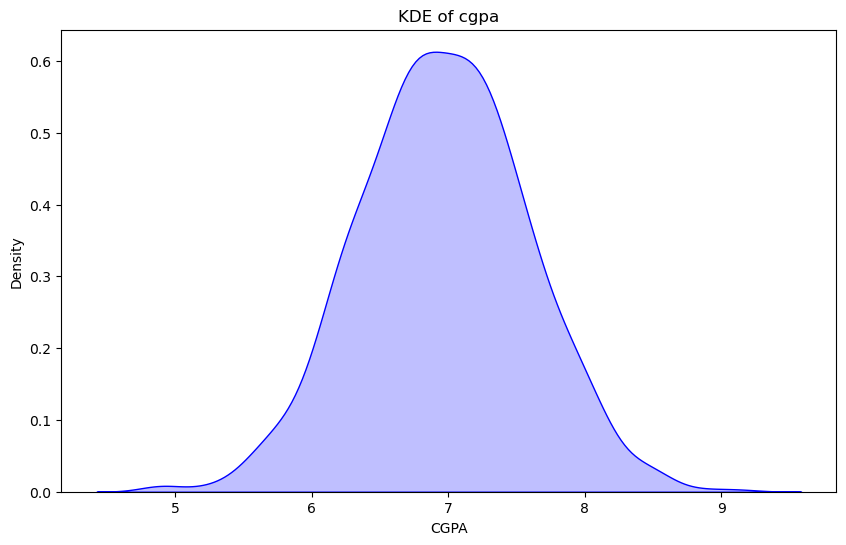

In [4]:
plt.figure(figsize=(10, 6))
plt.title('KDE of cgpa')
plt.xlabel('CGPA')
sns.kdeplot(df['cgpa'], color='blue', shade=True)
plt.show()

C:\Users\parth\AppData\Local\Temp\ipykernel_17256\1739604031.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['placement_exam_marks'], color='blue', shade=True)


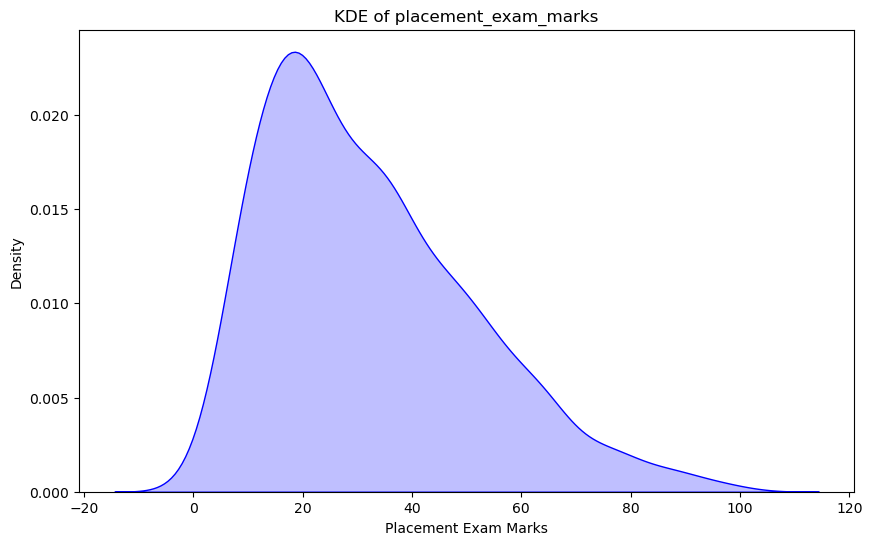

In [5]:
plt.figure(figsize=(10, 6))
plt.title('KDE of placement_exam_marks')
plt.xlabel('Placement Exam Marks')
sns.kdeplot(df['placement_exam_marks'], color='blue', shade=True)
plt.show()

In [6]:
df['placement_exam_marks'].skew()

0.8356419499466834

In [7]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

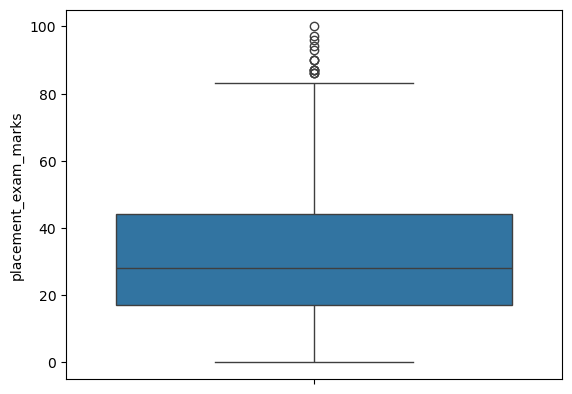

In [8]:
sns.boxplot(df['placement_exam_marks'])

In [10]:
percentile25=df['placement_exam_marks'].quantile(0.25)
percentile75=df['placement_exam_marks'].quantile(0.75)

In [11]:
percentile25, percentile75

(17.0, 44.0)

In [12]:
iqr = percentile75 - percentile25

In [13]:
upper_limit = percentile75 + (1.5 * iqr)
lower_limit = percentile25 - (1.5 * iqr)

In [14]:
upper_limit, lower_limit

(84.5, -23.5)

In [15]:
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [16]:
df[df['placement_exam_marks'] < lower_limit]

,cgpa,placement_exam_marks,placed


In [17]:
#trimming
df = df[(df['placement_exam_marks'] >= lower_limit) & (df['placement_exam_marks'] <= upper_limit)]

In [18]:
df.shape

(985, 3)

C:\Users\parth\AppData\Local\Temp\ipykernel_17256\1739604031.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['placement_exam_marks'], color='blue', shade=True)


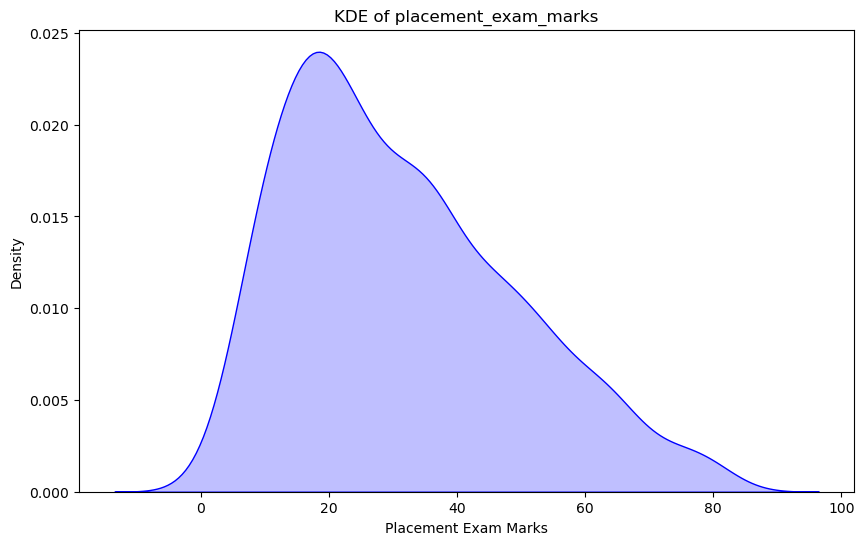

In [19]:
plt.figure(figsize=(10, 6))
plt.title('KDE of placement_exam_marks')
plt.xlabel('Placement Exam Marks')
sns.kdeplot(df['placement_exam_marks'], color='blue', shade=True)
plt.show()

<Axes: ylabel='placement_exam_marks'>

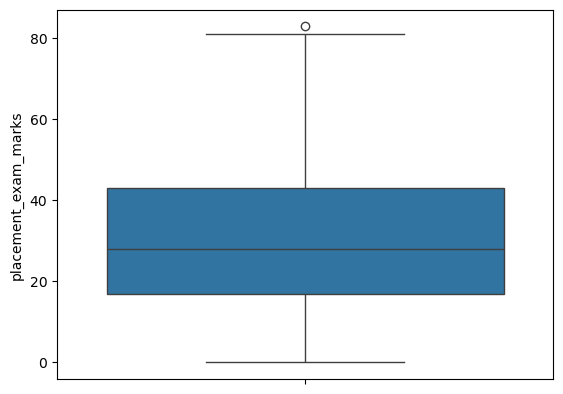

In [20]:
sns.boxplot(df['placement_exam_marks'])

In [21]:
# capping

In [22]:
new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

In [23]:
new_df_cap.shape

(985, 3)

C:\Users\parth\AppData\Local\Temp\ipykernel_17256\2104288254.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(new_df_cap['placement_exam_marks'], color='blue', shade=True)


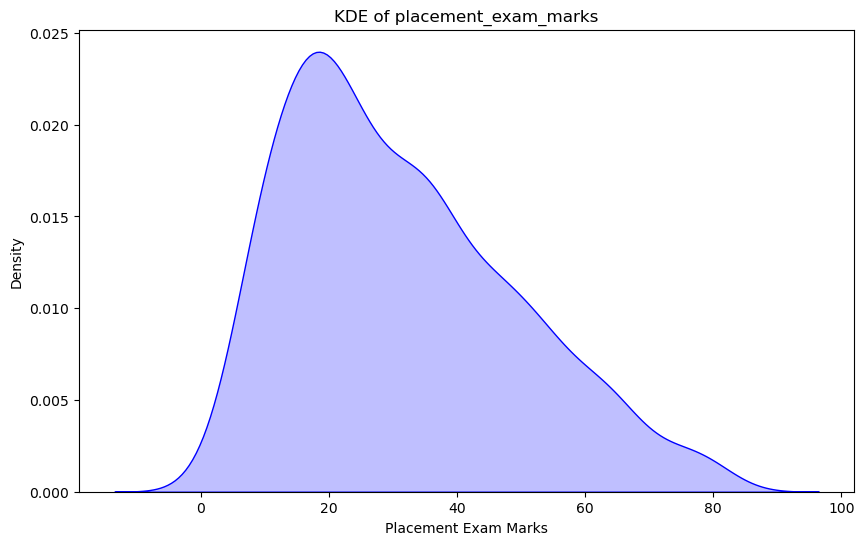

In [24]:
plt.figure(figsize=(10, 6))
plt.title('KDE of placement_exam_marks')
plt.xlabel('Placement Exam Marks')
sns.kdeplot(new_df_cap['placement_exam_marks'], color='blue', shade=True)
plt.show()